# Etapa 3 — Pipeline de Detección y Clasificación de Razas de Perros

## Configuración

In [73]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv

ROOT = Path.cwd()
src_path = str(ROOT / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

#cargar variables de env
env_file = ROOT / ".env.local.example" 
if not env_file.exists():
    env_file = ROOT / "src" / ".env.local.example"

load_dotenv(env_file)


def parse_path(env_value: str) -> Path:
    clean_path = env_value.replace("../", "")
    return ROOT / clean_path

#leer parametros env
DATASET_PATH = parse_path(os.getenv("DATASET_PATH", "../data/dataset"))
OUTPUT_PATH  = parse_path(os.getenv("OUTPUT_PATH", "../output"))
IMAGE_SIZE   = int(os.getenv("IMAGE_SIZE", 224))

#Construimos las rutas de los modelos leyendo las variables
MODEL_PATH = parse_path(os.getenv("MODEL_PATH", "../models"))
CHECKPOINTS = {
    "resnet18_finetuned": MODEL_PATH / os.getenv("RESNET18_MODEL_NAME", "resnet18_finetuned.pth"),
    "cnn_custom": MODEL_PATH / os.getenv("CNN_CUSTOM_MODEL_NAME", "cnn_custom.pth"),
}

#configuracion yolo
YOLO_MODEL_NAME = os.getenv("YOLO_MODEL", "yolov8n.pt")
CONF_THRESHOLD  = float(os.getenv("YOLO_CONF_THRESHOLD", 0.25))
DOG_CLASS_ID    = int(os.getenv("YOLO_DOG_CLASS_ID", 16))

#modelo clasificador 
ACTIVE_MODEL = "resnet18_finetuned"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [55]:
from lib.services.classifier_service import ClassifierService
from lib.services.detection_service import DetectionService


classifier = ClassifierService(
    checkpoints=CHECKPOINTS,
    image_size=IMAGE_SIZE,
    dataset_path=DATASET_PATH,
    output_path=OUTPUT_PATH,
    active_model=ACTIVE_MODEL,
)

detector = DetectionService(
    classifier=classifier,
    yolo_model=YOLO_MODEL_NAME,
    conf_threshold=CONF_THRESHOLD,
    dog_class_id=DOG_CLASS_ID,
)


## Función de visualización del pipeline completo

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


#Corre detect_dogs → recorta → classify_detected_dog sobre una imagen y dibuja bounding boxes, raza predicha y scores.
def run_pipeline(image_path: str, figsize=(10, 8), show=True):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    #saca alto y ancho para pasarle a yolo
    height, width = image.shape[:2]
    detections = []
    raw_detections = detector.detect_dogs(image) #detect_dogs procesa con yolo y devuelve coordenadas

    #recorte y clasificacion de cada perro detectado
    for (box, det_score) in raw_detections:
        x1, y1, x2, y2 = detector._clip_xyxy(*[int(v) for v in box], height, width)
        crop = image[y1:y2, x1:x2]      #recorta perro
        breed, breed_score = detector.classify_detected_dog(crop)  #pasa el cuadro a resnet y devuelve la raza y score
        detections.append(((x1, y1, x2, y2), det_score, breed, breed_score))

    #dibujar bounding boxes y mostrar resultados
    if show:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(image_rgb)

        for (x1, y1, x2, y2), det_score, breed, breed_score in detections:
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            )
            ax.add_patch(rect)
            label = f"{breed} {breed_score:.2f} | det {det_score:.2f}"
            ax.text(
                x1, max(0, y1 - 4), label,
                color="white", fontsize=9,
                bbox=dict(facecolor="darkgreen", alpha=0.75, pad=1),
            )

        ax.set_title(f"{len(detections)} perro(s) detectado(s) (conf \u2265 {CONF_THRESHOLD})", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        if not detections:
            print("\u26a0\ufe0f  No se detectó ningún perro en la imagen.")
        for i, (_, det_score, breed, breed_score) in enumerate(detections, 1):
            print(f"  Perro {i}: raza='{breed}' | score clasificación={breed_score:.3f} | conf. detección={det_score:.3f}")

    return detections

## Un solo perro

Imagen: c:\Users\maxir\OneDrive\Documents\tp2_cv\tuia-dog-recognition-app\data\dataset\test\Cocker\04.jpg | Raza real: Cocker

0: 640x640 1 cat, 1 dog, 60.1ms
Speed: 3.2ms preprocess, 60.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


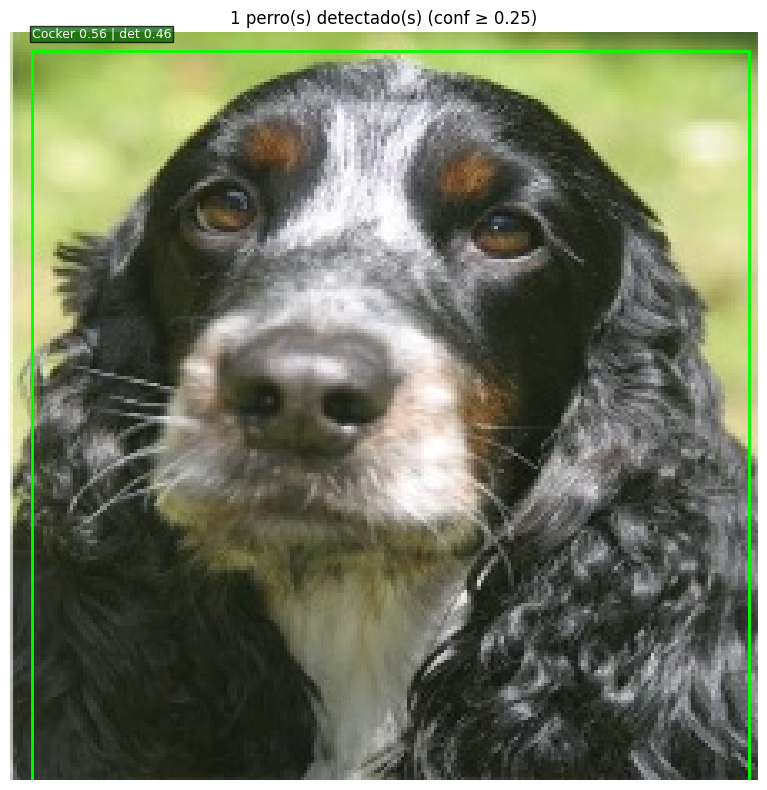

  Perro 1: raza='Cocker' | score clasificación=0.560 | conf. detección=0.460


[((6, 5, 221, 224), 0.45953935384750366, 'Cocker', 0.5597302913665771)]

In [ ]:
import random

todas_las_imagenes = list((DATASET_PATH / "test").rglob("*.jpg"))

#elegir una imagen al azar de test
sample_image = random.choice(todas_las_imagenes)

# raza real
raza_real = sample_image.parent.name

print(f"Imagen: {sample_image} | Raza real: {raza_real}")

run_pipeline(str(sample_image))

## Multiples perros en la misma imagen



0: 320x640 6 dogs, 54.5ms
Speed: 1.9ms preprocess, 54.5ms inference, 2.9ms postprocess per image at shape (1, 3, 320, 640)


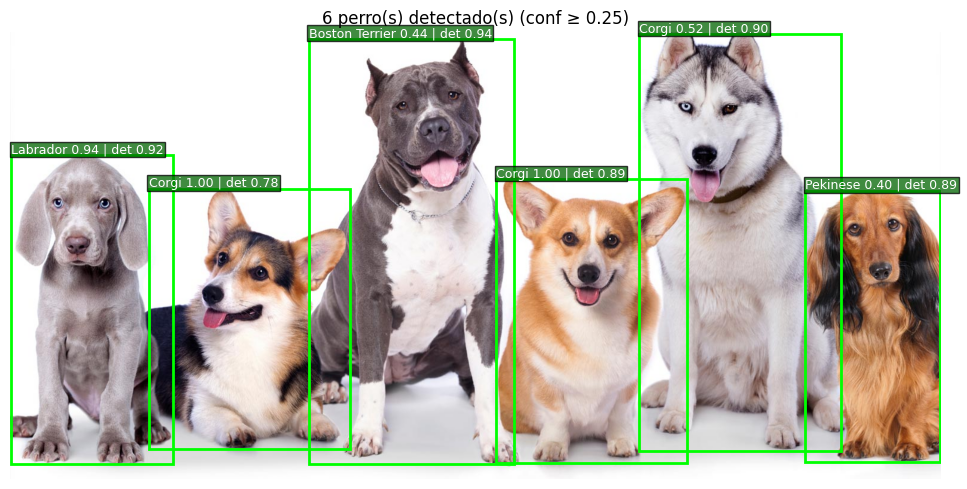

  Perro 1: raza='Boston Terrier' | score clasificación=0.445 | conf. detección=0.941
  Perro 2: raza='Labrador' | score clasificación=0.937 | conf. detección=0.921
  Perro 3: raza='Corgi' | score clasificación=0.518 | conf. detección=0.900
  Perro 4: raza='Corgi' | score clasificación=0.997 | conf. detección=0.895
  Perro 5: raza='Pekinese' | score clasificación=0.398 | conf. detección=0.893
  Perro 6: raza='Corgi' | score clasificación=0.998 | conf. detección=0.780


[((500, 12, 845, 724),
  0.9408002495765686,
  'Boston Terrier',
  0.4445796012878418),
 ((2, 207, 272, 725), 0.9212190508842468, 'Labrador', 0.9370751976966858),
 ((1054, 3, 1393, 702), 0.9004518985748291, 'Corgi', 0.5175247192382812),
 ((815, 247, 1135, 723), 0.8946327567100525, 'Corgi', 0.9965691566467285),
 ((1333, 266, 1559, 721), 0.8934999108314514, 'Pekinese', 0.39793717861175537),
 ((232, 263, 570, 700), 0.7796269059181213, 'Corgi', 0.9979007244110107)]

In [80]:
run_pipeline("data/dataset/multiples_perros.jpg")

## Escena compleja (perros + otros objetos)


0: 480x640 1 dog, 6 teddy bears, 72.0ms
Speed: 2.0ms preprocess, 72.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


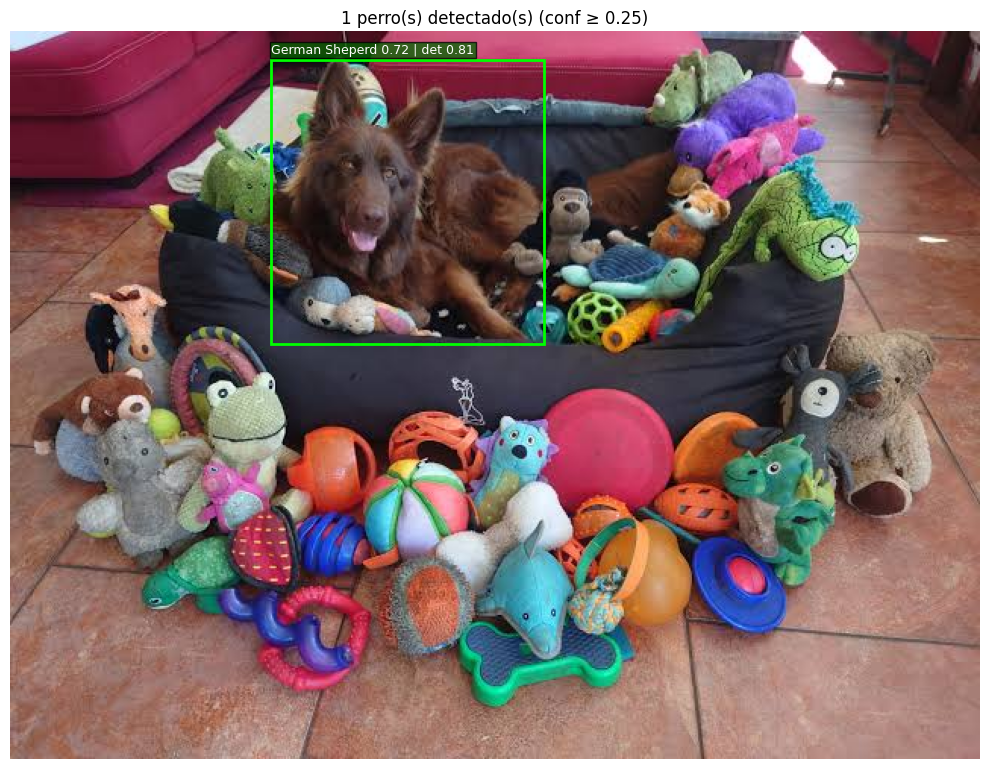

  Perro 1: raza='German Sheperd' | score clasificación=0.721 | conf. detección=0.807


[((172, 18, 352, 206),
  0.8072589635848999,
  'German Sheperd',
  0.7210161685943604)]

In [81]:
run_pipeline("data/dataset/perros_objetos.jpg")